SIT720 Task 8.1D - Sydney Housing Price Prediction and Decision Support System 
Dhyaan | 226517659 | Deakin University 
Suburbs: Chatswood 2067, Parramatta 2150, Blacktown 2148

Part 1: Problem Definition and Data Collection
-Imports and configuration

In [1]:
import warnings, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.bbox'] = 'tight'

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('Setup complete.')

Setup complete.


-Loading

In [2]:
DATA_PATH = 'data/sydney_housing_dataset.xlsx'
df = pd.read_excel(DATA_PATH, sheet_name='main')

print('Shape:', df.shape)
print('\nColumns:', df.columns.tolist())
df.head()

Shape: (102, 18)

Columns: ['property_id', 'suburb', 'postcode', 'street_address', 'property_type', 'bedrooms', 'bathrooms', 'car_spaces', 'land_size_m2', 'floor_area_m2', 'sale_price', 'sale_date', 'sale_method', 'agency', 'agent', 'description', 'listing_url', 'notes']


,property_id,suburb,postcode,street_address,property_type,bedrooms,bathrooms,car_spaces,land_size_m2,floor_area_m2,sale_price,sale_date,sale_method,agency,agent,description,listing_url,notes
0,CHA001,Chatswood,2067,14 Jacques Street,House,3,2,2,505.0,NaN,3290000,2026-08-29,Auction,Shead Property,Tony (Anthony) Walker; Isabella (Ni Yang Fang)...,Offering a prized opportunity to build your dr...,https://www.domain.com.au/14-jacques-street-ch...,Sold prior to auction
1,CHA002,Chatswood,2067,11 Crick Street,House,5,3,3,746.1,NaN,6200000,2026-08-21,Private treaty,Shead Property,Isabella (Ni Yang Fang) Yan; Tony (Anthony) Wa...,Available on the market for the first time sin...,https://www.domain.com.au/11-crick-street-chat...,Inspect by Appointment; Features- Study
2,CHA003,Chatswood,2067,16 Fontaine Street,House,4,2,3,576.0,NaN,3300000,2026-07-15,Auction,Shead Property,Tony (Anthony) Walker; Isabella (Ni Yang Fang)...,Classic character and exciting future potentia...,https://www.domain.com.au/16-fontaine-street-c...,Inspect by Appointment; Features- Built in war...
3,CHA004,Chatswood,2067,10 Goodchap Road,House,3,2,2,318.5,NaN,2325000,2026-07-07,Private treaty,DiJones-Chatswood,Adam Wong; Nathan Zhuang,Superb Full Brick Torrens Title Duplex in Cove...,https://www.domain.com.au/10-goodchap-road-cha...,Sold prior to auction; Features- Close to scho...
4,CHA005,Chatswood,2067,5 Johnson Street,House,2,1,3,493.0,NaN,2290000,2026-07-02,Private treaty,Ray White AY Realty Chatswood,Andy Yeung; Grace Lin,Take your place in one of Chatswood's most des...,https://www.domain.com.au/5-johnson-street-cha...,Features- Study


Types and integrity checks

In [3]:
num_cols = ['bedrooms','bathrooms','car_spaces','land_size_m2','floor_area_m2','sale_price']
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')
df['sale_date'] = pd.to_datetime(df['sale_date'], errors='coerce')
df['postcode']  = df['postcode'].astype(str)

checks = {
    'sale_price outside $300k–$15M' : ~df['sale_price'].between(3e5, 1.5e7),
    'bedrooms outside 0–8'          : ~df['bedrooms'].between(0, 8),
    'bathrooms outside 1–6'         : ~df['bathrooms'].between(1, 6),
    'car_spaces missing'            : df['car_spaces'].isna(),
    'unparseable sale_date'         : df['sale_date'].isna(),
    'House with no land size'       : (df['property_type'] == 'House') & df['land_size_m2'].isna(),
    'duplicate listing_url'         : df['listing_url'].duplicated(keep=False),
    'duplicate property_id'         : df['property_id'].duplicated(keep=False),
}
for name, mask in checks.items():
    print(f'{name:35s}: {int(mask.sum())}')

sale_price outside $300k–$15M      : 0
bedrooms outside 0–8               : 0
bathrooms outside 1–6              : 0
car_spaces missing                 : 0
unparseable sale_date              : 0
House with no land size            : 0
duplicate listing_url              : 0
duplicate property_id              : 0


Dataset composition

In [4]:
comp = df.groupby(['suburb','property_type']).size().unstack(fill_value=0)
comp['Total'] = comp.sum(axis=1)
display(comp)

print('\nSale period by suburb:')
display(df.groupby('suburb')['sale_date'].agg(['min','max','count']))
print('\nSale method:', df['sale_method'].value_counts().to_dict())

property_type,Apartment,House,Townhouse,Total
suburb,,,,
Blacktown,15,15,4,34
Chatswood,16,16,2,34
Parramatta,15,15,4,34



Sale period by suburb:


,min,max,count
suburb,,,
Blacktown,2026-06-26,2026-09-17,34
Chatswood,2026-02-09,2026-09-01,34
Parramatta,2025-10-28,2026-09-16,34



Sale method: {'Private treaty': 84, 'Auction': 18}


Missingness

In [5]:
miss = (df.isna().mean() * 100).round(1)
display(miss[miss > 0].sort_values(ascending=False).rename('% missing').to_frame())

# Missingness is structural, not random — confirm it
print('\nland_size_m2 missing, by property type:')
print(df.groupby('property_type')['land_size_m2'].apply(lambda s: f'{s.isna().mean()*100:.0f}%'))
print('\nfloor_area_m2 missing, by property type:')
print(df.groupby('property_type')['floor_area_m2'].apply(lambda s: f'{s.isna().mean()*100:.0f}%'))

,% missing
floor_area_m2,50.0
land_size_m2,49.0
notes,49.0
description,1.0



land_size_m2 missing, by property type:
property_type
Apartment    100%
House          0%
Townhouse     40%
Name: land_size_m2, dtype: object

floor_area_m2 missing, by property type:
property_type
Apartment      0%
House        100%
Townhouse     50%
Name: floor_area_m2, dtype: object


Descriptive statistics by segment

In [6]:
seg = (df.groupby(['suburb','property_type'])['sale_price']
         .agg(['count','median','mean','std','min','max'])
         .round(0).astype('Int64'))
display(seg)

count   median     mean      std      min      max
suburb     property_type                                                    
Blacktown  Apartment         15   435000   463767    65737   415000   600000
           House             15  1221000  1222367   285874   880000  1900000
           Townhouse          4   815000   812500    92150   700000   920000
Chatswood  Apartment         16  1080000  1332981   566717   745000  2628000
           House             16  3295000  3394688  1105112  2150000  6200000
           Townhouse          2  1490000  1490000    42426  1460000  1520000
Parramatta Apartment         15   569000   556867    84255   320000   660000
           House             15  1610000  1708293   395816  1230000  2650000
           Townhouse          4   924000   967000   268991   720000  1300000

Part 2: Data Understanding and Feature Engineering

Figure 1: price distribution, raw and log

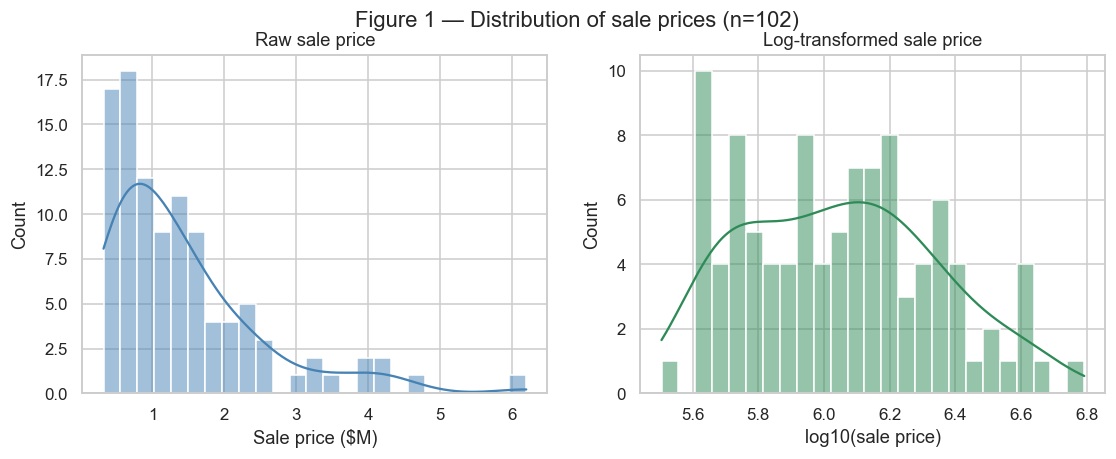

Skewness  raw : 1.81
Skewness  log : 0.29


In [7]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['sale_price']/1e6, bins=25, kde=True, ax=ax[0], color='steelblue')
ax[0].set(xlabel='Sale price ($M)', ylabel='Count', title='Raw sale price')
sns.histplot(np.log10(df['sale_price']), bins=25, kde=True, ax=ax[1], color='seagreen')
ax[1].set(xlabel='log10(sale price)', ylabel='Count', title='Log-transformed sale price')
plt.suptitle('Figure 1 — Distribution of sale prices (n=102)')
plt.show()

print('Skewness  raw :', round(df['sale_price'].skew(), 2))
print('Skewness  log :', round(np.log(df['sale_price']).skew(), 2))

Figure 2: suburb × property type

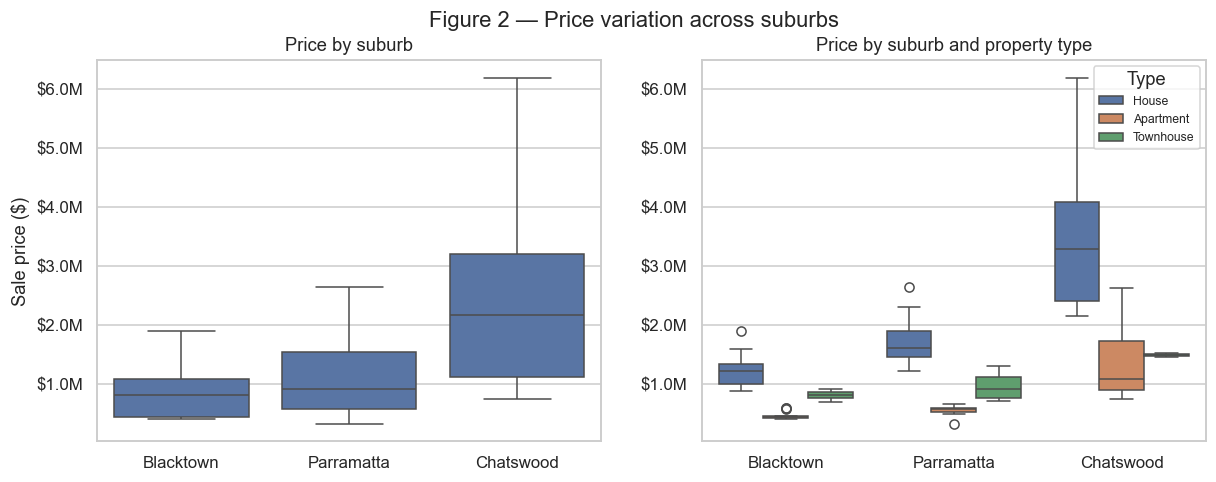

suburb
Blacktown      815000.0
Parramatta     924000.0
Chatswood     2175000.0
Name: sale_price, dtype: float64


In [8]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
order = ['Blacktown','Parramatta','Chatswood']
sns.boxplot(data=df, x='suburb', y='sale_price', order=order, ax=ax[0])
ax[0].set(title='Price by suburb', xlabel='', ylabel='Sale price ($)')
sns.boxplot(data=df, x='suburb', y='sale_price', hue='property_type', order=order, ax=ax[1])
ax[1].set(title='Price by suburb and property type', xlabel='', ylabel='')
ax[1].legend(title='Type', fontsize=8)
for a in ax:
    a.yaxis.set_major_formatter(lambda x, p: f'${x/1e6:.1f}M')
plt.suptitle('Figure 2 — Price variation across suburbs')
plt.show()

print(df.groupby('suburb')['sale_price'].median().round(0).sort_values())

Figure 3: time trend 

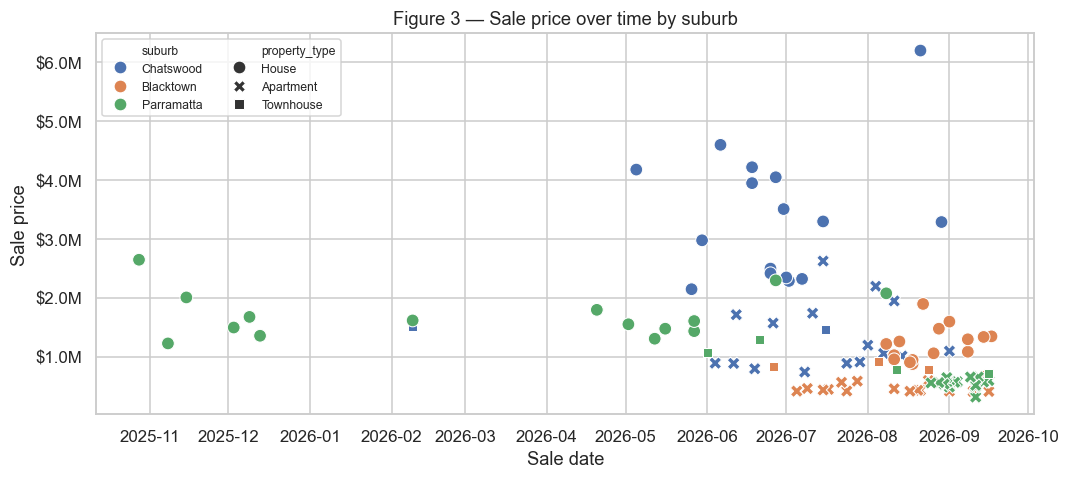

,min,max,months
suburb,,,
Blacktown,2026-06-26,2026-09-17,2.7
Chatswood,2026-02-09,2026-09-01,6.7
Parramatta,2025-10-28,2026-09-16,10.6


In [9]:
fig, ax = plt.subplots(figsize=(11, 4.5))
sns.scatterplot(data=df, x='sale_date', y='sale_price', hue='suburb',
                style='property_type', s=70, ax=ax)
ax.set(title='Figure 3 — Sale price over time by suburb', xlabel='Sale date', ylabel='Sale price')
ax.yaxis.set_major_formatter(lambda x, p: f'${x/1e6:.1f}M')
ax.legend(fontsize=8, ncol=2)
plt.show()

# Quantify the collection-window mismatch noted in Part 1
span = df.groupby('suburb')['sale_date'].agg(['min','max'])
span['months'] = ((span['max'] - span['min']).dt.days / 30.44).round(1)
display(span)

Figure 4: correlations and pre-engineering feature ranking

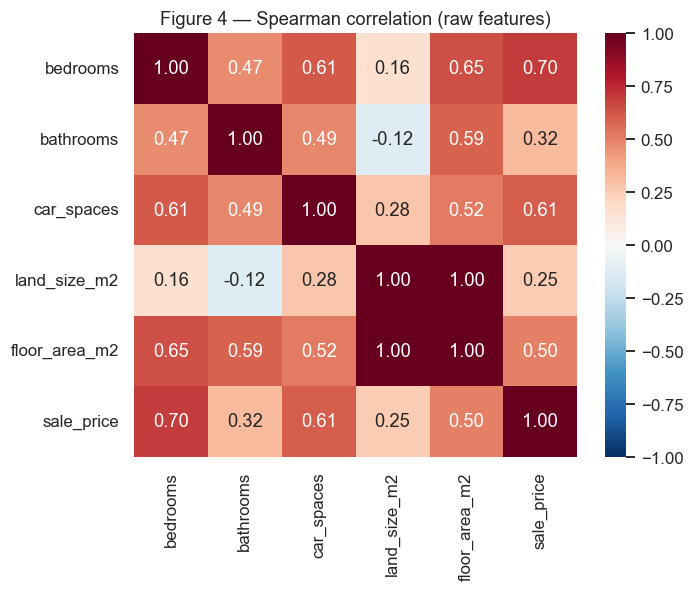

Correlation with sale_price, ranked:
bedrooms         0.700
car_spaces       0.606
floor_area_m2    0.502
bathrooms        0.318
land_size_m2     0.253
Name: sale_price, dtype: float64


In [10]:
base = ['bedrooms','bathrooms','car_spaces','land_size_m2','floor_area_m2','sale_price']
corr = df[base].corr(method='spearman')

fig, ax = plt.subplots(figsize=(6.5, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title('Figure 4 — Spearman correlation (raw features)')
plt.show()

print('Correlation with sale_price, ranked:')
print(corr['sale_price'].drop('sale_price').abs().sort_values(ascending=False).round(3))

Outlier identification

In [11]:
df['z_within_segment'] = (df.groupby(['suburb','property_type'])['sale_price']
                            .transform(lambda s: (s - s.mean()) / s.std(ddof=0)))
outliers = df.reindex(df['z_within_segment'].abs().sort_values(ascending=False).index).head(8)
display(outliers[['property_id','suburb','property_type','bedrooms','bathrooms',
                  'land_size_m2','sale_price','z_within_segment','notes']]
        .assign(z_within_segment=lambda d: d['z_within_segment'].round(2)))

,property_id,suburb,property_type,bedrooms,bathrooms,land_size_m2,sale_price,z_within_segment,notes
86,PAR019,Parramatta,Apartment,1,1,NaN,320000,-2.91,NaN
1,CHA002,Chatswood,House,5,3,746.1,6200000,2.62,Inspect by Appointment; Features- Study
82,PAR015,Parramatta,House,3,2,942.0,2650000,2.46,NaN
41,BLA008,Blacktown,House,7,4,739.8,1900000,2.45,Features- Study
24,CHA025,Chatswood,Apartment,3,2,NaN,2628000,2.36,"Features- Air conditioning, Gym, Intercom, Bui..."
52,BLA019,Blacktown,Apartment,3,2,NaN,600000,2.15,NaN
57,BLA024,Blacktown,Apartment,2,2,NaN,590000,1.99,NaN
59,BLA026,Blacktown,Apartment,2,2,NaN,570000,1.67,NaN


Feature engineering

In [12]:
d = df.copy()

# --- Structural ---
d['total_rooms']  = d['bedrooms'] + d['bathrooms']
d['bath_per_bed'] = d['bathrooms'] / d['bedrooms'].replace(0, np.nan)

# land_size_m2 and floor_area_m2 are structurally complementary: land is recorded
# for houses/townhouses only, floor area for apartments/townhouses only, and just
# 2 of 102 rows have both. Neither can be imputed from the other, so they are
# combined into one complete feature plus an indicator of which measure it is.
d['size_m2']      = d['land_size_m2'].fillna(d['floor_area_m2'])
d['size_is_land'] = d['land_size_m2'].notna().astype(int)
d['size_m2']      = d.groupby(['suburb','property_type'])['size_m2'].transform(
                        lambda s: s.fillna(s.median()))

# --- Temporal (retained for EDA; months_elapsed is excluded from the model) ---
d['sale_month']     = d['sale_date'].dt.month
d['months_elapsed'] = ((d['sale_date'] - d['sale_date'].min()).dt.days / 30.44).round(2)

# --- Text-derived (from the agent description) ---
d['description'] = d['description'].fillna('')
d['desc_word_count'] = d['description'].str.split().str.len()
d['desc_exclaims']   = d['description'].str.count('!')

KEYWORDS = {
    'kw_renovated'  : r'renovat|refurbish|updated|modern kitchen',
    'kw_original'   : r'original condition|needs work|renovator|potential to|as is',
    'kw_pool'       : r'\bpool\b',
    'kw_view'       : r'\bview[s]?\b|outlook|district view',
    'kw_transport'  : r'\bstation\b|\bmetro\b|light rail|bus stop',
    'kw_school'     : r'\bschool\b|catchment|education',
    'kw_luxury'     : r'luxur|prestig|premium|architect|bespoke',
    'kw_investment' : r'investor|rental return|tenant|yield',
    'kw_granny_flat': r'granny flat|dual occupancy|duplex potential',
    'kw_north'      : r'north[- ]?facing|northerly aspect',
}
for name, pat in KEYWORDS.items():
    d[name] = d['description'].str.lower().str.contains(pat, regex=True).astype(int)

# --- Target ---
d['log_price'] = np.log(d['sale_price'])

print('size_m2 missing:', d['size_m2'].isna().sum())
display(d.groupby(['property_type','size_is_land'])['size_m2'].agg(['count','median']))
print('\nKeyword prevalence (% of listings):')
print((d[list(KEYWORDS)].mean() * 100).round(1).sort_values(ascending=False))

size_m2 missing: 0


count  median
property_type size_is_land               
Apartment     0                46   99.00
House         1                46  560.35
Townhouse     0                 4  156.50
              1                 6  199.50


Keyword prevalence (% of listings):
kw_transport      68.6
kw_investment     52.9
kw_renovated      38.2
kw_school         36.3
kw_luxury         33.3
kw_view           29.4
kw_pool           16.7
kw_north          16.7
kw_original       12.7
kw_granny_flat     9.8
dtype: float64


In [13]:
print('months_elapsed vs log price:')
print(f"  overall (all segments pooled)   rho = "
      f"{d['months_elapsed'].corr(d['log_price'], method='spearman'):+.3f}")
for (s, t), g in d.groupby(['suburb','property_type']):
    if len(g) >= 10:
        r = g['months_elapsed'].corr(g['log_price'], method='spearman')
        print(f'  {s:11s} {t:10s} n={len(g):2d}     rho = {r:+.3f}')

print('\nMean months_elapsed by segment (reveals collection-order bias):')
print(d.groupby(['suburb','property_type'])['months_elapsed'].mean().round(1))

months_elapsed vs log price:
  overall (all segments pooled)   rho = -0.545
  Blacktown   Apartment  n=15     rho = -0.397
  Blacktown   House      n=15     rho = +0.526
  Chatswood   Apartment  n=16     rho = +0.335
  Chatswood   House      n=16     rho = -0.091
  Parramatta  Apartment  n=15     rho = +0.214
  Parramatta  House      n=15     rho = +0.054

Mean months_elapsed by segment (reveals collection-order bias):
suburb      property_type
Blacktown   Apartment         9.3
            House             9.9
            Townhouse         9.4
Chatswood   Apartment         8.6
            House             8.0
            Townhouse         6.0
Parramatta  Apartment        10.3
            House             4.3
            Townhouse         8.7
Name: months_elapsed, dtype: float64


Figure 5: do the engineered features carry signal?

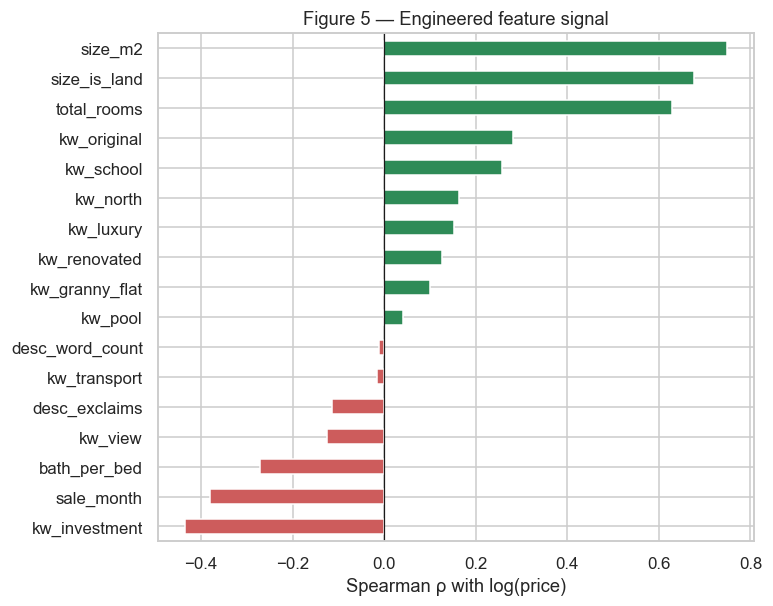

,ρ
kw_investment,-0.436
sale_month,-0.381
bath_per_bed,-0.272
kw_view,-0.126
desc_exclaims,-0.113
kw_transport,-0.015
desc_word_count,-0.012
kw_pool,0.041
kw_granny_flat,0.101
kw_renovated,0.127


In [14]:
eng = ['total_rooms','bath_per_bed','size_m2','size_is_land','sale_month',
       'desc_word_count','desc_exclaims'] + list(KEYWORDS)

sig = (d[eng + ['log_price']].corr(method='spearman')['log_price']
         .drop('log_price').sort_values())

fig, ax = plt.subplots(figsize=(7, 6))
sig.plot.barh(ax=ax, color=np.where(sig > 0, 'seagreen', 'indianred'))
ax.set(xlabel='Spearman ρ with log(price)', ylabel='',
       title='Figure 5 — Engineered feature signal')
ax.axvline(0, color='k', lw=0.8)
plt.show()
display(sig.round(3).to_frame('ρ'))

Finding price per metre square and Leakage check

In [15]:
# price_per_m2 is a tempting feature but is derived from the target — including it
# would leak the answer. Computed here for EDA commentary ONLY, never as a model input.
eda_ppm = (d.loc[d['property_type'] == 'House', 'sale_price'] /
           d.loc[d['property_type'] == 'House', 'land_size_m2'])
print('Land $/m² for houses, by suburb:')
print(d.loc[d['property_type'] == 'House'].assign(ppm=eda_ppm)
        .groupby('suburb')['ppm'].median().round(0))

LEAKY = ['price_per_m2', 'sale_price']   # excluded from all feature matrices

# Excluded for structural or confounding reasons rather than leakage:
#   land_size_m2, floor_area_m2 — each ~50% missing by construction; superseded by size_m2
#   has_land, has_floor_area    — near-duplicates of property_type
#   months_elapsed              — confounded with collection order
DROPPED = ['land_size_m2','floor_area_m2','has_land','has_floor_area','months_elapsed']

Land $/m² for houses, by suburb:
suburb
Blacktown     1847.0
Chatswood     6645.0
Parramatta    3206.0
Name: ppm, dtype: float64


Part 3: Model Development and Evaluation

Feature matrix and held-out split

In [16]:
from sklearn.model_selection import train_test_split

TARGET = 'log_price'
NUMERIC = ['bedrooms','bathrooms','car_spaces','size_m2','size_is_land',
           'total_rooms','bath_per_bed','sale_month',
           'desc_word_count','desc_exclaims'] + list(KEYWORDS)
CATEGORICAL = ['suburb','property_type','sale_method']
FEATURES = NUMERIC + CATEGORICAL

assert not any(f in FEATURES for f in DROPPED + LEAKY), 'Excluded feature leaked back in'
print(f'Features: {len(NUMERIC)} numeric + {len(CATEGORICAL)} categorical')   # expect 20 + 3

X, y = d[FEATURES].copy(), d[TARGET].copy()

# 12 properties held out for Part 5 (ML vs LLM vs human), stratified by suburb.
# This split happens BEFORE any training or tuning.
X_dev, X_hold, y_dev, y_hold, idx_dev, idx_hold = train_test_split(
    X, y, d.index, test_size=12, random_state=RANDOM_STATE, stratify=d['suburb'])

print(f'Development set: {len(X_dev)}   Held-out set: {len(X_hold)}')
print(d.loc[idx_hold, 'suburb'].value_counts().to_dict())

Features: 20 numeric + 3 categorical
Development set: 90   Held-out set: 12
{'Blacktown': 4, 'Chatswood': 4, 'Parramatta': 4}


Preprocessing and the three models

In [17]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

pre_linear = ColumnTransformer([
    ('num', Pipeline([('imp', SimpleImputer(strategy='median')),
                      ('sc',  StandardScaler())]), NUMERIC),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), CATEGORICAL),
])
pre_tree = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), NUMERIC),
    ('cat', OneHotEncoder(handle_unknown='ignore'), CATEGORICAL),
])

models = {
    'Ridge Regression': Pipeline([
        ('pre', pre_linear),
        ('model', Ridge(alpha=1.0, random_state=RANDOM_STATE))]),

    'Random Forest': Pipeline([
        ('pre', pre_tree),
        ('model', RandomForestRegressor(
            n_estimators=500, max_depth=12, min_samples_leaf=2,
            max_features='sqrt', random_state=RANDOM_STATE, n_jobs=-1))]),

    'Gradient Boosting': Pipeline([
        ('pre', pre_tree),
        ('model', GradientBoostingRegressor(
            n_estimators=300, learning_rate=0.05, max_depth=3,
            min_samples_leaf=3, subsample=0.8, random_state=RANDOM_STATE))]),
}
for name, pipe in models.items():
    print(f'{name:20s} -> {type(pipe.named_steps["model"]).__name__}')

Ridge Regression     -> Ridge
Random Forest        -> RandomForestRegressor
Gradient Boosting    -> GradientBoostingRegressor


k-fold CV, evaluated in dollars

In [18]:
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def dollar_metrics(y_true_log, y_pred_log):
    yt, yp = np.exp(y_true_log), np.exp(y_pred_log)
    return {'RMSE ($)': np.sqrt(mean_squared_error(yt, yp)),
            'MAE ($)' : mean_absolute_error(yt, yp),
            'MAPE (%)': np.mean(np.abs((yt - yp) / yt)) * 100,
            'R² (log)': r2_score(y_true_log, y_pred_log),
            'R² ($)'  : r2_score(yt, yp)}

results = {}
for name, pipe in models.items():
    results[name] = dollar_metrics(y_dev, cross_val_predict(pipe, X_dev, y_dev, cv=cv, n_jobs=-1))

baseline_df = pd.DataFrame(results).T
display(baseline_df.style.format({'RMSE ($)':'${:,.0f}', 'MAE ($)':'${:,.0f}',
                                  'MAPE (%)':'{:.1f}%', 'R² (log)':'{:.3f}', 'R² ($)':'{:.3f}'}))

,RMSE ($),MAE ($),MAPE (%),R² (log),R² ($)
Ridge Regression,"$622,480","$326,710",18.2%,0.875,0.675
Random Forest,"$610,647","$333,482",20.6%,0.842,0.687
Gradient Boosting,"$408,046","$245,068",15.5%,0.917,0.860


Figure 6: fold-level variance

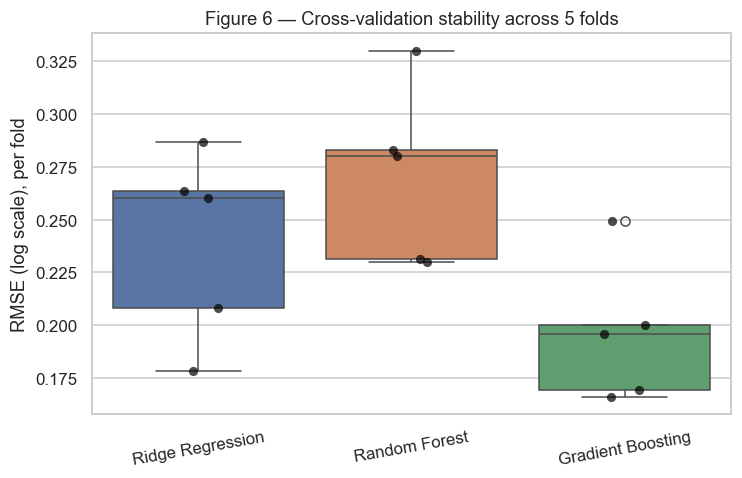

Ridge Regression     mean=0.2393  std=0.0399
Random Forest        mean=0.2708  std=0.0373
Gradient Boosting    mean=0.1963  std=0.0298


In [19]:
from sklearn.model_selection import cross_val_score

fold_scores = {name: -cross_val_score(pipe, X_dev, y_dev, cv=cv,
                                      scoring='neg_root_mean_squared_error', n_jobs=-1)
               for name, pipe in models.items()}

fig, ax = plt.subplots(figsize=(7.5, 4.5))
sns.boxplot(data=pd.DataFrame(fold_scores), ax=ax)
sns.stripplot(data=pd.DataFrame(fold_scores), ax=ax, color='black', size=6, alpha=0.7)
ax.set(ylabel='RMSE (log scale), per fold',
       title='Figure 6 — Cross-validation stability across 5 folds')
plt.xticks(rotation=10); plt.show()

for name, s in fold_scores.items():
    print(f'{name:20s} mean={s.mean():.4f}  std={s.std():.4f}')

Figure 7: learning curves

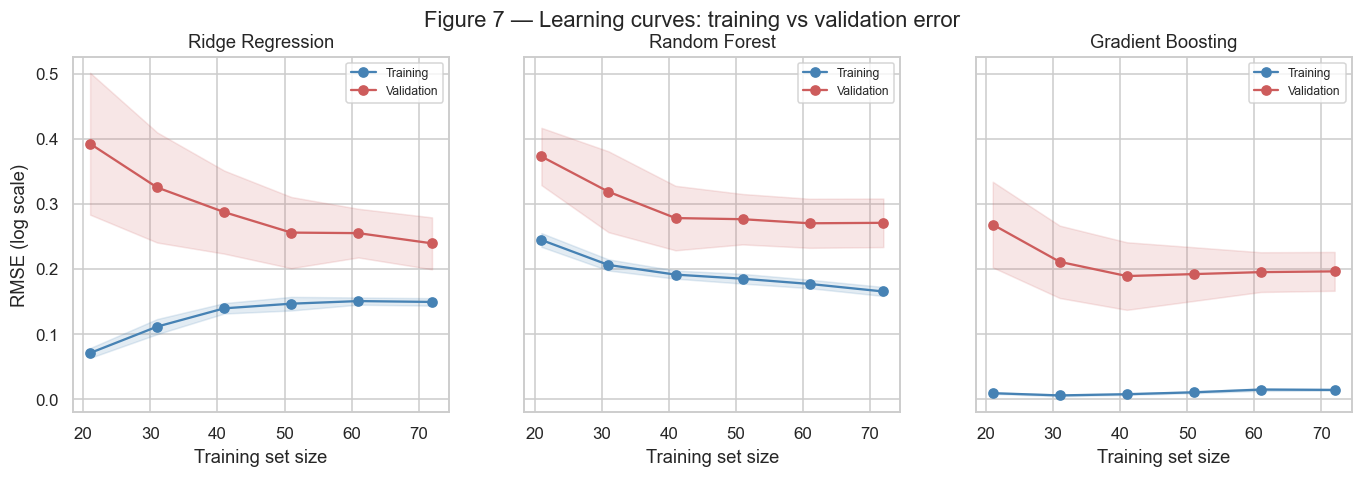

In [20]:
from sklearn.model_selection import learning_curve

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)
for ax, (name, pipe) in zip(axes, models.items()):
    sizes, tr, va = learning_curve(pipe, X_dev, y_dev, cv=cv, n_jobs=-1,
                                   train_sizes=np.linspace(0.3, 1.0, 6),
                                   scoring='neg_root_mean_squared_error')
    ax.plot(sizes, -tr.mean(1), 'o-', label='Training',   color='steelblue')
    ax.plot(sizes, -va.mean(1), 'o-', label='Validation', color='indianred')
    ax.fill_between(sizes, -tr.mean(1)-tr.std(1), -tr.mean(1)+tr.std(1), alpha=.15, color='steelblue')
    ax.fill_between(sizes, -va.mean(1)-va.std(1), -va.mean(1)+va.std(1), alpha=.15, color='indianred')
    ax.set(title=name, xlabel='Training set size'); ax.legend(fontsize=8)
axes[0].set_ylabel('RMSE (log scale)')
plt.suptitle('Figure 7 — Learning curves: training vs validation error'); plt.show()

Light hyperparameter tuning

In [21]:
from sklearn.model_selection import GridSearchCV

grids = {
    'Ridge Regression' : {'model__alpha': [0.001, 0.01, 0.1, 0.5, 1, 5, 10, 50]},
    'Random Forest'    : {'model__max_depth': [4, 6, 12, None],
                          'model__min_samples_leaf': [1, 2, 4]},
    'Gradient Boosting': {'model__learning_rate': [0.01, 0.03, 0.05, 0.1],
                          'model__max_depth': [2, 3, 4]},
}
tuned = {}
for name, pipe in models.items():
    gs = GridSearchCV(pipe, grids[name], cv=cv,
                      scoring='neg_root_mean_squared_error', n_jobs=-1).fit(X_dev, y_dev)
    tuned[name] = gs.best_estimator_
    print(f'{name:20s} best={gs.best_params_}  CV RMSE(log)={-gs.best_score_:.4f}')

tuned_df = pd.DataFrame({name: dollar_metrics(y_dev, cross_val_predict(est, X_dev, y_dev, cv=cv, n_jobs=-1))
                         for name, est in tuned.items()}).T
display(tuned_df.style.format({'RMSE ($)':'${:,.0f}', 'MAE ($)':'${:,.0f}',
                               'MAPE (%)':'{:.1f}%', 'R² (log)':'{:.3f}', 'R² ($)':'{:.3f}'}))

Ridge Regression     best={'model__alpha': 0.01}  CV RMSE(log)=0.2293
Random Forest        best={'model__max_depth': None, 'model__min_samples_leaf': 1}  CV RMSE(log)=0.2475
Gradient Boosting    best={'model__learning_rate': 0.05, 'model__max_depth': 4}  CV RMSE(log)=0.1897


,RMSE ($),MAE ($),MAPE (%),R² (log),R² ($)
Ridge Regression,"$601,223","$329,147",18.5%,0.887,0.697
Random Forest,"$554,310","$299,438",18.5%,0.867,0.742
Gradient Boosting,"$400,332","$231,328",14.4%,0.922,0.866


Figure 8: predicted vs actual for the best model

Best model by out-of-fold MAE: Gradient Boosting


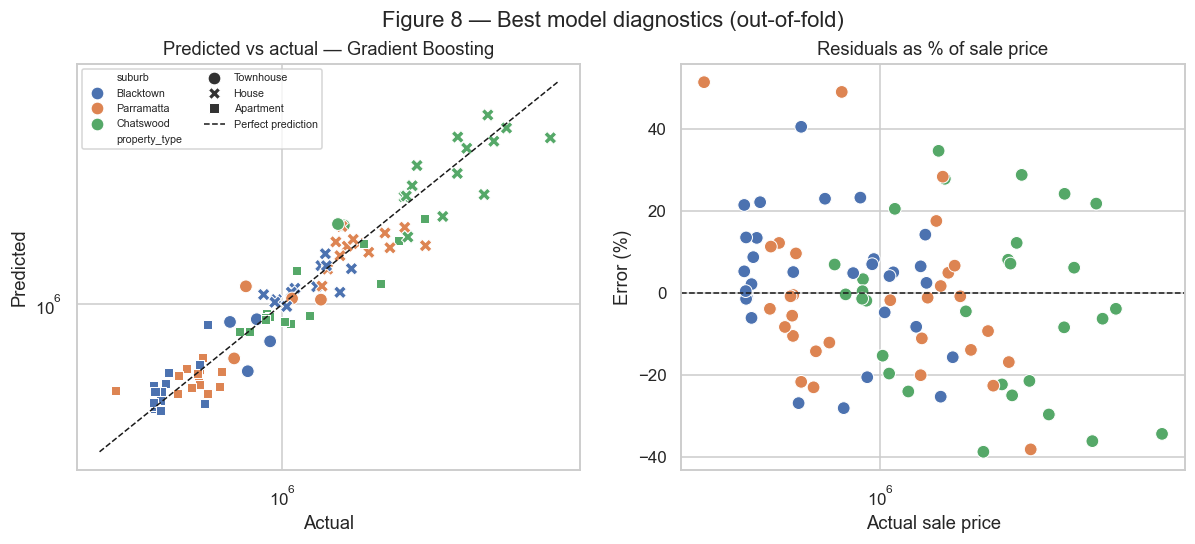

In [22]:
BEST = tuned_df['MAE ($)'].idxmin()
print('Best model by out-of-fold MAE:', BEST)

best_model = tuned[BEST]
oof_best = cross_val_predict(best_model, X_dev, y_dev, cv=cv, n_jobs=-1)
act, prd = np.exp(y_dev), np.exp(oof_best)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))
sns.scatterplot(x=act, y=prd, hue=d.loc[idx_dev,'suburb'],
                style=d.loc[idx_dev,'property_type'], s=70, ax=ax[0])
lim = [act.min()*0.9, act.max()*1.05]
ax[0].plot(lim, lim, 'k--', lw=1, label='Perfect prediction')
ax[0].set(xscale='log', yscale='log', xlabel='Actual', ylabel='Predicted',
          title=f'Predicted vs actual — {BEST}')
ax[0].legend(fontsize=7, ncol=2)

sns.scatterplot(x=act, y=(prd-act)/act*100, hue=d.loc[idx_dev,'suburb'],
                s=70, ax=ax[1], legend=False)
ax[1].axhline(0, color='k', ls='--', lw=1)
ax[1].set(xscale='log', xlabel='Actual sale price', ylabel='Error (%)',
          title='Residuals as % of sale price')
plt.suptitle('Figure 8 — Best model diagnostics (out-of-fold)'); plt.show()

Figure 9: permutation importance

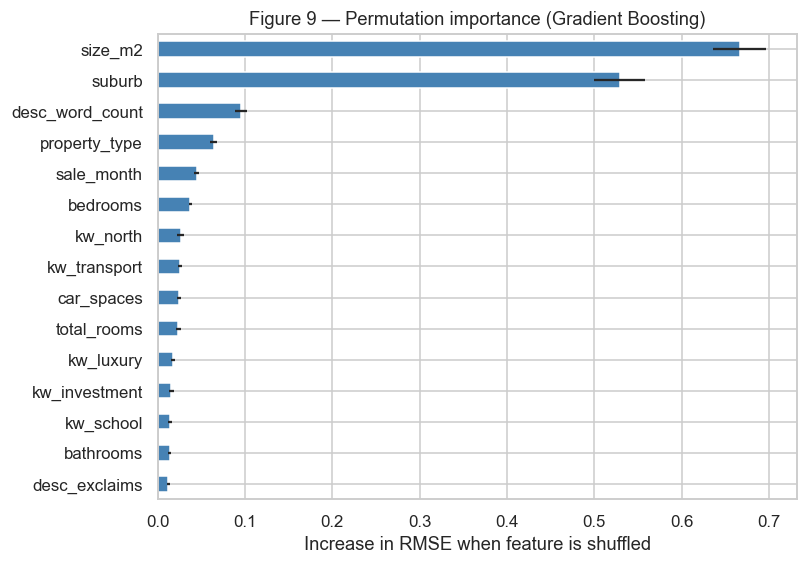

,importance
size_m2,0.6667
suburb,0.5292
desc_word_count,0.0958
property_type,0.0641
sale_month,0.0447
bedrooms,0.0376
kw_north,0.0266
kw_transport,0.0261
car_spaces,0.0246
total_rooms,0.0239


In [23]:
from sklearn.inspection import permutation_importance

best_model.fit(X_dev, y_dev)
pi = permutation_importance(best_model, X_dev, y_dev, n_repeats=30,
                            random_state=RANDOM_STATE, n_jobs=-1,
                            scoring='neg_root_mean_squared_error')
imp_mean = pd.Series(pi.importances_mean, index=FEATURES).sort_values(ascending=False).head(15)
imp_std  = pd.Series(pi.importances_std,  index=FEATURES)

fig, ax = plt.subplots(figsize=(7.5, 5.5))
imp_mean.sort_values().plot.barh(ax=ax, color='steelblue',
                                 xerr=imp_std[imp_mean.sort_values().index])
ax.set(xlabel='Increase in RMSE when feature is shuffled',
       title=f'Figure 9 — Permutation importance ({BEST})')
plt.show()
display(imp_mean.round(4).to_frame('importance'))

Part 4: Investigating Prediction Failures

Identifying the five largest errors

In [24]:
err = d.loc[idx_dev, ['property_id','suburb','property_type','bedrooms','bathrooms',
                      'car_spaces','size_m2','size_is_land','sale_date','sale_method',
                      'sale_price','notes','description']].copy()
err['predicted'] = np.exp(oof_best)
err['error_$']   = err['predicted'] - err['sale_price']
err['abs_err_$'] = err['error_$'].abs()
err['error_pct'] = err['error_$'] / err['sale_price'] * 100

SHOW = ['property_id','suburb','property_type','bedrooms','bathrooms','size_m2',
        'sale_price','predicted','error_$','error_pct']
fmt = {'sale_price':'${:,.0f}', 'predicted':'${:,.0f}',
       'error_$':'${:+,.0f}', 'error_pct':'{:+.1f}%', 'size_m2':'{:.0f}'}

top5 = err.nlargest(5, 'abs_err_$')
print(' Five largest errors by DOLLAR value')
display(top5[SHOW].style.format(fmt).hide(axis='index'))

print('\n Five largest errors by PERCENTAGE')
top5_pct = err.reindex(err['error_pct'].abs().sort_values(ascending=False).index).head(5)
display(top5_pct[SHOW].style.format(fmt).hide(axis='index'))

 Five largest errors by DOLLAR value


property_id,suburb,property_type,bedrooms,bathrooms,size_m2,sale_price,predicted,error_$,error_pct
CHA002,Chatswood,House,5,3,746,"$6,200,000","$4,070,160","$-2,129,840",-34.4%
CHA012,Chatswood,House,3,1,558,"$3,950,000","$2,523,036","$-1,426,964",-36.1%
PAR015,Parramatta,House,3,2,942,"$2,650,000","$1,639,264","$-1,010,736",-38.1%
CHA008,Chatswood,House,5,3,765,"$4,050,000","$4,934,939","$+884,939",+21.9%
CHA014,Chatswood,House,4,2,392,"$2,980,000","$2,097,282","$-882,718",-29.6%



 Five largest errors by PERCENTAGE


property_id,suburb,property_type,bedrooms,bathrooms,size_m2,sale_price,predicted,error_$,error_pct
PAR019,Parramatta,Apartment,1,1,50,"$320,000","$484,744","$+164,744",+51.5%
PAR032,Parramatta,Townhouse,2,1,251,"$780,000","$1,163,018","$+383,018",+49.1%
BLA019,Blacktown,Apartment,3,2,179,"$600,000","$843,558","$+243,558",+40.6%
CHA019,Chatswood,Apartment,2,2,137,"$1,951,000","$1,195,497","$-755,503",-38.7%
PAR015,Parramatta,House,3,2,942,"$2,650,000","$1,639,264","$-1,010,736",-38.1%


In [25]:
for _, r in top5.iterrows():
    print('=' * 90)
    print(f"{r.property_id} | {r.suburb} {r.property_type} | {r.bedrooms}bed {r.bathrooms}bath "
          f"| {r.size_m2:.0f} m² ({'land' if r.size_is_land else 'internal'})")
    print(f"Sold {r.sale_date:%d %b %Y} by {r.sale_method}")
    print(f"Actual ${r.sale_price:,.0f}   Predicted ${r.predicted:,.0f}   "
          f"Error ${r['error_$']:+,.0f} ({r.error_pct:+.1f}%)")
    print(f"Notes: {r.notes if pd.notna(r.notes) else '—'}")
    print(f"Description (first 400 chars):\n  {str(r.description)[:400]}...")
print('=' * 90)

CHA002 | Chatswood House | 5bed 3bath | 746 m² (land)
Sold 21 Aug 2026 by Private treaty
Actual $6,200,000   Predicted $4,070,160   Error $-2,129,840 (-34.4%)
Notes: Inspect by Appointment; Features- Study
Description (first 400 chars):
  Available on the market for the first time since originally constructed in 1999, this excellent family home offers a timeless elegance and a sense of grandeur in a quiet pocket. Situated on a staggering 746sqm (approx.) block with a frontage over 15m, it offers both a formal and casual arrangement of lounge and dining settings, prioritising a relaxed family connectivity as well as indoor and outdo...
CHA012 | Chatswood House | 3bed 1bath | 558 m² (land)
Sold 18 Jun 2026 by Private treaty
Actual $3,950,000   Predicted $2,523,036   Error $-1,426,964 (-36.1%)
Notes: Sold prior to auction; Features- Air conditioning, Close to transport, Close to shops, Close to schools
Description (first 400 chars):
  Under Contract | Prime Chatswood Eastside Landholding 

Figure 10: which segments are intrinsically harder?

n  mean_abs_pct  bias_pct
suburb     property_type                            
Chatswood  Townhouse       2          31.3      31.3
Parramatta Townhouse       4          20.7       3.8
Blacktown  Townhouse       4          19.1      -5.2
Chatswood  House          14          18.0      -2.5
Parramatta Apartment      13          13.3      -0.3
           House          13          13.3      -4.2
Chatswood  Apartment      14          12.9      -8.4
Blacktown  Apartment      14          12.0       7.0
           House          12          10.4       1.4

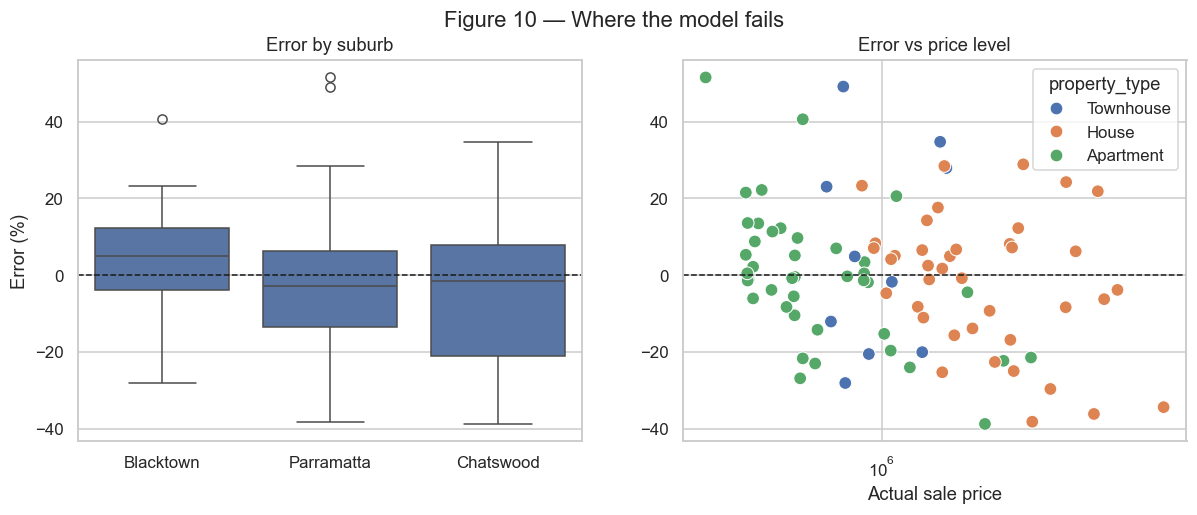

Mean |error| by price quartile:
price_q
Q1 (lowest)     10.5
Q2              15.0
Q3              12.9
Q4 (highest)    19.1
Name: error_pct, dtype: float64


In [26]:
seg_err = (err.groupby(['suburb','property_type'])
              .agg(n=('error_pct','size'),
                   mean_abs_pct=('error_pct', lambda s: s.abs().mean()),
                   bias_pct=('error_pct','mean'))
              .round(1).sort_values('mean_abs_pct', ascending=False))
display(seg_err)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
sns.boxplot(data=err, x='suburb', y='error_pct', order=['Blacktown','Parramatta','Chatswood'], ax=ax[0])
ax[0].axhline(0, color='k', ls='--', lw=1)
ax[0].set(title='Error by suburb', xlabel='', ylabel='Error (%)')

sns.scatterplot(data=err, x='sale_price', y='error_pct', hue='property_type', s=70, ax=ax[1])
ax[1].axhline(0, color='k', ls='--', lw=1)
ax[1].set(xscale='log', title='Error vs price level', xlabel='Actual sale price', ylabel='')
plt.suptitle('Figure 10 — Where the model fails'); plt.show()

print('Mean |error| by price quartile:')
err['price_q'] = pd.qcut(err['sale_price'], 4, labels=['Q1 (lowest)','Q2','Q3','Q4 (highest)'])
print(err.groupby('price_q')['error_pct'].apply(lambda s: s.abs().mean()).round(1))

Part 5: Human Judgement, Machine Learning, and Large Language Models

LLM Prompt

In [27]:
hold = d.loc[idx_hold].copy()
hold['ml_prediction'] = np.exp(best_model.predict(X_hold))

lines = []
for i, (_, r) in enumerate(hold.iterrows(), 1):
    lines.append(
        f"{i}. {r.suburb} NSW — {r.property_type}, {r.bedrooms} bed, {r.bathrooms} bath, "
        f"{r.car_spaces:.0f} car, {r.size_m2:.0f} m² "
        f"({'land' if r.size_is_land else 'internal'}), sold {r.sale_date:%B %Y} "
        f"by {r.sale_method.lower()}.\n   Agent description: {str(r.description)[:300]}...")

print("Estimate the sale price in AUD for each of the following Sydney properties.\n"
      "Give a single number per property, no ranges, no explanation.\n")
print('\n'.join(lines))

hold[['property_id','suburb','property_type','bedrooms','bathrooms','size_m2',
      'sale_date','sale_price','ml_prediction']].to_csv('data/part5_holdout.csv', index=False)
print('\nSaved data/part5_holdout.csv — add llm_prediction and human_prediction columns.')

Estimate the sale price in AUD for each of the following Sydney properties.
Give a single number per property, no ranges, no explanation.

1. Blacktown NSW — House, 3 bed, 1 bath, 1 car, 835 m² (land), sold August 2026 by auction.
   Agent description: Located within walking distance to premier schools, shops, transport and in one of the districts best areas, rare find is this oversized three bedroom brick veneer family home boasting open plan living areas which offers warm, everyday living and leaves nothing to be desired by way of comfort and ap...
2. Chatswood NSW — Apartment, 2 bed, 2 bath, 1 car, 130 m² (internal), sold June 2026 by private treaty.
   Agent description: Level 26 Regency Sub-Penthouse with North-East Stunning Views
Positioned high on Level 26 of the iconic "Regency" building, this sub-penthouse apartment captures breathtaking panoramic views with an enviable sunny north-east aspect, skyline and ocean view outlook from the balcony. Filled with natura...
3. Chatswood

Tabulating in csv ML vs LLM vs Human

In [28]:
part5 = pd.read_csv('data/part5_holdout.csv')

# Order 1-12, matching the prompt.
part5['llm_prediction']       = [1230000, 1720000, 4100000, 950000, 1550000, 650000,
                                 480000, 1850000, 580000, 2200000, 1600000, 1250000]   # ChatGPT, search enabled
part5['llm_clean_prediction'] = [1250000, 1650000, 4100000, 1150000, 1600000, 650000,
                                 520000, 1900000, 580000, 2650000, 1550000, 1350000]   # ChatGPT, search disabled
part5['human_prediction']     = [1200000, 1650000, 4100000, 1000000, 1580000, 600000,
                                 500000, 1950000, 575000, 3100000, 1450000, 1400000]   # own estimate

PRED_COLS = ['ml_prediction','llm_prediction','llm_clean_prediction','human_prediction']
assert (part5[PRED_COLS] > 0).all().all(), 'Missing values'
part5.to_csv('data/part5_holdout.csv', index=False)

display(part5[['property_id','suburb','property_type','bedrooms','size_m2','sale_price'] + PRED_COLS])

,property_id,suburb,property_type,bedrooms,size_m2,sale_price,ml_prediction,llm_prediction,llm_clean_prediction,human_prediction
0,BLA015,Blacktown,House,3,835.0,1221000,1.448430e+06,1230000,1250000,1200000
1,CHA030,Chatswood,Apartment,2,130.0,1717500,1.179281e+06,1720000,1650000,1650000
2,CHA016,Chatswood,House,5,243.0,4180000,2.468130e+06,4100000,4100000,4100000
3,BLA011,Blacktown,House,3,682.9,910000,1.116397e+06,950000,1150000,1000000
4,PAR004,Parramatta,House,3,461.6,1610000,1.534832e+06,1550000,1600000,1580000
5,PAR018,Parramatta,Apartment,2,91.0,660000,5.249999e+05,650000,650000,600000
6,BLA029,Blacktown,Apartment,2,128.0,465000,5.292641e+05,480000,520000,500000
7,BLA008,Blacktown,House,7,739.8,1900000,1.599112e+06,1850000,1900000,1950000
8,PAR017,Parramatta,Apartment,2,94.0,575000,5.308558e+05,580000,580000,575000
9,CHA015,Chatswood,House,4,359.0,2150000,2.491183e+06,2200000,2650000,3100000


Comparison

 Valuation approaches compared on 12 held-out properties


,MAE ($),MAPE (%),RMSE ($),Bias (%),Within 10%,Worst
ML (Gradient Boosting),"$361,246",20.0%,"$563,344",-0.1%,2/12,CHA016 -41.0%
LLM (search enabled),"$30,542",2.1%,"$38,797",+0.4%,12/12,BLA011 +4.4%
LLM (search disabled),"$95,125",7.0%,"$167,748",+5.4%,9/12,BLA011 +26.4%
Human (own estimate),"$139,875",8.7%,"$285,007",+4.3%,10/12,CHA015 +44.2%


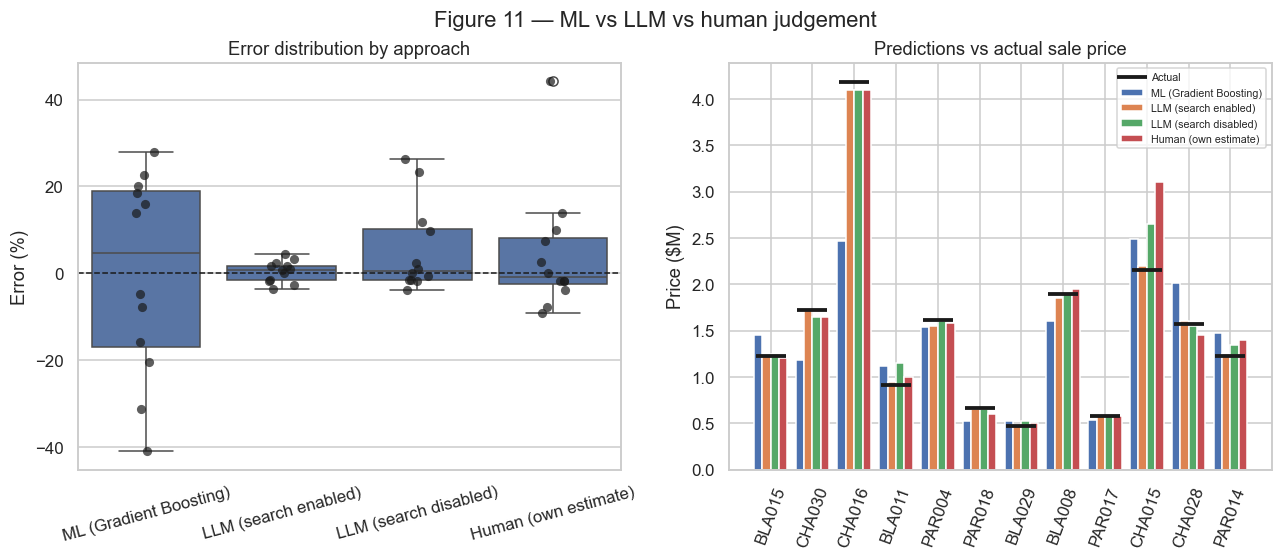

Identical predictions across the two LLM runs: 3/12
Correlation between LLM runs: r = 0.9902

MAPE by property type:
  ML (Gradient Boosting)   {'Apartment': 20.3, 'House': 19.8}
  LLM (search enabled)     {'Apartment': 1.5, 'House': 2.5}
  LLM (search disabled)    {'Apartment': 3.9, 'House': 9.2}
  Human (own estimate)     {'Apartment': 5.7, 'House': 10.9}


In [29]:
approaches = {'ML (Gradient Boosting)'  : 'ml_prediction',
              'LLM (search enabled)'    : 'llm_prediction',
              'LLM (search disabled)'   : 'llm_clean_prediction',
              'Human (own estimate)'    : 'human_prediction'}

rows = {}
for label, col in approaches.items():
    e = part5[col] - part5['sale_price']
    p = e / part5['sale_price'] * 100
    part5[col.replace('_prediction','_err_pct')] = p.round(1)
    rows[label] = {'MAE ($)': e.abs().mean(), 'MAPE (%)': p.abs().mean(),
                   'RMSE ($)': np.sqrt((e**2).mean()), 'Bias (%)': p.mean(),
                   'Within 10%': f'{(p.abs() <= 10).sum()}/12',
                   'Worst': f"{part5.loc[p.abs().idxmax(),'property_id']} {p[p.abs().idxmax()]:+.1f}%"}

print(' Valuation approaches compared on 12 held-out properties')
display(pd.DataFrame(rows).T.style.format({'MAE ($)':'${:,.0f}','RMSE ($)':'${:,.0f}',
                                           'MAPE (%)':'{:.1f}%','Bias (%)':'{:+.1f}%'}))

err_cols = [c.replace('_prediction','_err_pct') for c in approaches.values()]
labels   = dict(zip(err_cols, approaches.keys()))

fig, ax = plt.subplots(1, 2, figsize=(14, 4.8))
long = part5.melt(id_vars=['property_id'], value_vars=err_cols,
                  var_name='approach', value_name='error_pct')
long['approach'] = long['approach'].map(labels)
sns.boxplot(data=long, x='approach', y='error_pct', ax=ax[0])
sns.stripplot(data=long, x='approach', y='error_pct', color='k', size=6, alpha=.7, ax=ax[0])
ax[0].axhline(0, color='k', ls='--', lw=1)
ax[0].set(title='Error distribution by approach', xlabel='', ylabel='Error (%)')
ax[0].tick_params(axis='x', rotation=15)

x = np.arange(12); w = 0.2
for i, (label, col) in enumerate(approaches.items()):
    ax[1].bar(x + (i-1.5)*w, part5[col]/1e6, w, label=label)
ax[1].plot(x, part5['sale_price']/1e6, 'k_', ms=20, mew=2.5, label='Actual')
ax[1].set(xticks=x, xticklabels=part5['property_id'], ylabel='Price ($M)',
          title='Predictions vs actual sale price')
ax[1].tick_params(axis='x', rotation=70); ax[1].legend(fontsize=7)
plt.suptitle('Figure 11 — ML vs LLM vs human judgement'); plt.show()

# Evidence for the contamination finding (Section 5.2)
same = (part5['llm_prediction'] == part5['llm_clean_prediction']).sum()
r = np.corrcoef(part5['llm_prediction'], part5['llm_clean_prediction'])[0,1]
print(f'Identical predictions across the two LLM runs: {same}/12')
print(f'Correlation between LLM runs: r = {r:.4f}')

print('\nMAPE by property type:')
for label, col in approaches.items():
    m = (part5.assign(e=(part5[col]-part5.sale_price).abs()/part5.sale_price*100)
              .groupby('property_type')['e'].mean().round(1))
    print(f'  {label:24s} {m.to_dict()}')

Model for the app

In [30]:
import joblib, json, os

MODEL_DIR = 'model'
os.makedirs(MODEL_DIR, exist_ok=True)

final_model = tuned[BEST]
final_model.fit(X, y)          # refit on all 102 rows for deployment

resid = y_dev - cross_val_predict(tuned[BEST], X_dev, y_dev, cv=cv, n_jobs=-1)
resid_sd = float(np.std(resid))

joblib.dump(final_model, os.path.join(MODEL_DIR, 'gb_model.joblib'))
json.dump({'features'        : FEATURES,
           'model'           : BEST,
           'cv_mape'         : float(tuned_df.loc[BEST, 'MAPE (%)']),
           'cv_resid_sd_log' : resid_sd,
           'n_train'         : int(len(X))},
          open(os.path.join(MODEL_DIR, 'model_meta.json'), 'w'), indent=2)

print(f'Exported {BEST} to {os.path.abspath(MODEL_DIR)}')
print(f'  CV MAPE     : {tuned_df.loc[BEST, "MAPE (%)"]:.1f}%')
print(f'  Residual SD : {resid_sd:.4f} (log scale)')
print(f'  Features    : {len(FEATURES)}')
for f in os.listdir(MODEL_DIR):
    print(f'  {f:20s} {os.path.getsize(os.path.join(MODEL_DIR, f)):>10,} bytes')

Exported Gradient Boosting to C:\Users\dhyaa\SIT720_ML\SIT720_Task8.1D\model
  CV MAPE     : 14.4%
  Residual SD : 0.1906 (log scale)
  Features    : 23
  .ipynb_checkpoints            0 bytes
  gb_model.joblib         538,563 bytes
  model_meta.json             600 bytes


In [31]:
# Sanity check: reloading from disk and confirming predictions match, so the app
# and the notebook cannot silently diverge.
reloaded = joblib.load('model/gb_model.joblib')
meta = json.load(open('model/model_meta.json'))

check = np.allclose(reloaded.predict(X_hold[meta['features']]),
                    final_model.predict(X_hold[meta['features']]))
print('Reloaded model matches in-memory model:', check)

demo = pd.DataFrame([{**{c: 0 for c in NUMERIC},
                      'bedrooms': 3, 'bathrooms': 2, 'car_spaces': 1,
                      'size_m2': 550, 'size_is_land': 1, 'total_rooms': 5,
                      'bath_per_bed': 0.667, 'sale_month': 6,
                      'desc_word_count': 150, 'desc_exclaims': 0,
                      'suburb': 'Blacktown', 'property_type': 'House',
                      'sale_method': 'Private treaty'}])[meta['features']]
print(f"Demo — Blacktown 3bd house, 550 m²: ${np.exp(reloaded.predict(demo)[0]):,.0f}")

Reloaded model matches in-memory model: True
Demo — Blacktown 3bd house, 550 m²: $1,039,548


Sample CSV

In [32]:
sample = d.loc[idx_hold, ['suburb','property_type','bedrooms','bathrooms',
                          'car_spaces','size_m2','sale_method','sale_month','description']].copy()
sample['description'] = sample['description'].str[:200]
sample.to_csv('data/sample_batch.csv', index=False)
print(f'Saved data/sample_batch.csv — {sample.shape[0]} rows, {sample.shape[1]} columns')
display(sample.head(3))

Saved data/sample_batch.csv — 12 rows, 9 columns


,suburb,property_type,bedrooms,bathrooms,car_spaces,size_m2,sale_method,sale_month,description
48,Blacktown,House,3,1,1,835.0,Auction,8,Located within walking distance to premier sch...
29,Chatswood,Apartment,2,2,1,130.0,Private treaty,6,Level 26 Regency Sub-Penthouse with North-East...
15,Chatswood,House,5,3,1,243.0,Private treaty,5,Rare brand new masterpiece on the premium East...


Part 6: Final Deployment and Reflection

The trained model is deployed as a Streamlit application (`app.py`) that accepts either a single property through a form or a CSV for batch scoring. Feature engineering is reproduced identically to this notebook, so the deployed model receives exactly the inputs it was trained on.

To run:
pip install -r requirements.txt
streamlit run app.py

The application opens at `http://localhost:8501`. Screenshots are in `screenshots/`.

Repository: https://github.com/DhyaanMane/SIT720-Task8.1D-sydney-housing-predictor

In [34]:
print('='*70)
print('SUMMARY — SIT720 Task 8.1D')
print('='*70)
print(f'Dataset          : {len(df)} properties, {df.suburb.nunique()} suburbs')
print(f'Features         : {len(NUMERIC)} numeric + {len(CATEGORICAL)} categorical')
print(f'Best model       : {BEST}')
print(f'Cross-validated  : MAPE {tuned_df.loc[BEST,"MAPE (%)"]:.1f}%, '
      f'MAE ${tuned_df.loc[BEST,"MAE ($)"]:,.0f}, R² {tuned_df.loc[BEST,"R² (log)"]:.3f}')
print(f'Held-out (n=12)  : ML {rows["ML (Gradient Boosting)"]["MAPE (%)"]:.1f}%  |  '
      f'LLM-clean {rows["LLM (search disabled)"]["MAPE (%)"]:.1f}%  |  '
      f'Human {rows["Human (own estimate)"]["MAPE (%)"]:.1f}%')
print(f'Deployment       : model/gb_model.joblib -> app.py (Streamlit)')
print('='*70)

SUMMARY — SIT720 Task 8.1D
Dataset          : 102 properties, 3 suburbs
Features         : 20 numeric + 3 categorical
Best model       : Gradient Boosting
Cross-validated  : MAPE 14.4%, MAE $231,328, R² 0.922
Held-out (n=12)  : ML 20.0%  |  LLM-clean 7.0%  |  Human 8.7%
Deployment       : model/gb_model.joblib -> app.py (Streamlit)
